# Exercício 1 - Análise exploratória da base Titanic

**Disciplina:** Estatística para análise de dados  
**Estudante:** Adriano Pertile  
**Matrícula:** 202601914

## 1. Apresentação do conjunto de dados

- **Nome:** Titanic.
- **Fonte:** [`seaborn-data`](https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv).
- **Tema:** características dos passageiros e sobrevivência ao naufrágio Titanic.
- **Escolha:** possui variáveis numéricas, categóricas, booleanas e dados ausentes.
- **Dimensões:** 891 observações e 15 variáveis originais.


## 2. Carregamento e inspeção inicial

### Preparação do ambiente

A célula verifica e instala as bibliotecas necessárias.

In [1]:
import importlib.util
import subprocess
import sys

dependencias = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

ausentes = [pacote for modulo, pacote in dependencias.items() if importlib.util.find_spec(modulo) is None]

if ausentes:
    print("Instalando dependências ausentes:", ", ".join(ausentes))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *ausentes])
else:
    print("Todas as dependências já estão instaladas.")

Todas as dependências já estão instaladas.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="colorblind")

caminho_dados = Path("titanic.csv")
if not caminho_dados.exists():
    raise FileNotFoundError(
        "O arquivo titanic.csv deve estar na mesma pasta do notebook."
    )

df_original = pd.read_csv(caminho_dados)
df = df_original.copy()

ordem_sobrevivencia = ["Não", "Sim"]
ordem_sexo = ["Feminino", "Masculino"]
ordem_classe = ["1ª classe", "2ª classe", "3ª classe"]

df["sobreviveu"] = pd.Categorical(
    df["alive"].map({"no": "Não", "yes": "Sim"}),
    categories=ordem_sobrevivencia,
    ordered=True,
)
df["sexo"] = pd.Categorical(
    df["sex"].map({"female": "Feminino", "male": "Masculino"}),
    categories=ordem_sexo,
    ordered=True,
)
df["classe"] = pd.Categorical(
    df["class"].map({"First": "1ª classe", "Second": "2ª classe", "Third": "3ª classe"}),
    categories=ordem_classe,
    ordered=True,
)

# Novas colunas exemplificam a modificação de DataFrames apresentada na aula de tabelas.
df["tamanho_familia"] = df["sibsp"] + df["parch"] + 1
df["faixa_etaria"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, np.inf],
    labels=["Criança", "Adolescente", "Adulto jovem", "Adulto", "Idoso"],
    include_lowest=True,
)

print(f"Dimensões da base original: {df_original.shape[0]} linhas e {df_original.shape[1]} colunas")
print(f"DataFrame de análise: {df.shape[0]} linhas e {df.shape[1]} colunas")
print("As colunas adicionais contêm rótulos em português e variáveis derivadas.")
df.head()

Dimensões da base original: 891 linhas e 15 colunas
DataFrame de análise: 891 linhas e 20 colunas
As colunas adicionais contêm rótulos em português e variáveis derivadas.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sobreviveu,sexo,classe,tamanho_familia,faixa_etaria
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,Não,Masculino,3ª classe,2,Adulto jovem
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Sim,Feminino,1ª classe,2,Adulto
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Sim,Feminino,3ª classe,1,Adulto jovem
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Sim,Feminino,1ª classe,2,Adulto jovem
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,Não,Masculino,3ª classe,1,Adulto jovem


### Dicionário de variáveis

A tabela apresenta a descrição e o tipo conceitual das principais variáveis.

In [3]:
dicionario_variaveis = pd.DataFrame([
    ("survived", "Categórica binária", "Indica sobrevivência: 0 = não, 1 = sim"),
    ("pclass", "Categórica ordinal", "Classe da passagem representada por 1, 2 ou 3"),
    ("sex", "Categórica nominal", "Sexo registrado do passageiro"),
    ("age", "Quantitativa contínua", "Idade em anos"),
    ("sibsp", "Quantitativa discreta", "Quantidade de irmãos/cônjuges a bordo"),
    ("parch", "Quantitativa discreta", "Quantidade de pais/filhos a bordo"),
    ("fare", "Quantitativa contínua", "Tarifa paga"),
    ("embark_town", "Categórica nominal", "Cidade de embarque"),
    ("deck", "Categórica ordinal", "Convés registrado"),
    ("alone", "Booleana", "Indica se viajava sem familiares"),
    ("tamanho_familia", "Quantitativa discreta derivada", "sibsp + parch + 1"),
    ("faixa_etaria", "Categórica ordinal derivada", "Faixa construída a partir da idade"),
], columns=["variavel", "tipo_conceitual", "descricao"])

dicionario_variaveis

,variavel,tipo_conceitual,descricao
0,survived,Categórica binária,"Indica sobrevivência: 0 = não, 1 = sim"
1,pclass,Categórica ordinal,"Classe da passagem representada por 1, 2 ou 3"
2,sex,Categórica nominal,Sexo registrado do passageiro
3,age,Quantitativa contínua,Idade em anos
4,sibsp,Quantitativa discreta,Quantidade de irmãos/cônjuges a bordo
5,parch,Quantitativa discreta,Quantidade de pais/filhos a bordo
6,fare,Quantitativa contínua,Tarifa paga
7,embark_town,Categórica nominal,Cidade de embarque
8,deck,Categórica ordinal,Convés registrado
9,alone,Booleana,Indica se viajava sem familiares


In [4]:
qualidade = pd.DataFrame({
    "tipo_computacional": df_original.dtypes.astype(str),
    "valores_ausentes": df_original.isna().sum(),
    "percentual_ausente": df_original.isna().mean().mul(100).round(1),
    "valores_unicos": df_original.nunique(dropna=True),
})

display(qualidade)
print(f"Total de valores ausentes: {df_original.isna().sum().sum()}")
print(f"Linhas com perfis repetidos: {df_original.duplicated().sum()}")

,tipo_computacional,valores_ausentes,percentual_ausente,valores_unicos
survived,int64,0,0.0,2
pclass,int64,0,0.0,3
sex,object,0,0.0,2
age,float64,177,19.9,88
sibsp,int64,0,0.0,7
parch,int64,0,0.0,7
fare,float64,0,0.0,248
embarked,object,2,0.2,3
class,object,0,0.0,3
who,object,0,0.0,3


Total de valores ausentes: 869
Linhas com perfis repetidos: 107


In [5]:
# O critério de 1,5 vezes o intervalo interquartil (IQR) sinaliza valores
# extremos para inspeção, sem removê-los automaticamente.
colunas_numericas = ["age", "sibsp", "parch", "fare"]
q1 = df[colunas_numericas].quantile(0.25)
q3 = df[colunas_numericas].quantile(0.75)
iqr = q3 - q1

quantidade_fora_iqr = (
    (df[colunas_numericas] < (q1 - 1.5 * iqr))
    | (df[colunas_numericas] > (q3 + 1.5 * iqr))
).sum().sort_values(ascending=False)

quantidade_fora_iqr.rename("quantidade_fora_IQR").to_frame()

,quantidade_fora_IQR
parch,213
fare,116
sibsp,46
age,11


**Interpretação.** Há 177 idades ausentes (19,9%), 688 ausências em `deck` (77,2%) e 2 em `embarked` e `embark_town`. Não será feita imputação.

As 107 linhas repetidas não comprovam duplicidade, pois faltam identificadores. Valores extremos de `parch` e `fare` são plausíveis e serão mantidos.

### Causalidade

A base é **observacional**: sexo, classe, idade e tarifa não foram distribuídos aleatoriamente. Os resultados indicam associações, não causas.

Classe, tarifa e localização no navio podem atuar como fatores de confusão. A dinâmica da evacuação também não está registrada.

## 3. Estatísticas descritivas

In [6]:
colunas_resumo = ["age", "sibsp", "parch", "fare", "tamanho_familia"]
estatisticas = df[colunas_resumo].describe().T
estatisticas["IQR"] = estatisticas["75%"] - estatisticas["25%"]
estatisticas = (
    estatisticas[["count", "mean", "50%", "std", "min", "25%", "75%", "IQR", "max"]]
    .rename(columns={
        "count": "quantidade",
        "mean": "media",
        "50%": "mediana",
        "std": "desvio_padrao",
        "min": "minimo",
        "25%": "q1",
        "75%": "q3",
        "max": "maximo",
    })
)
estatisticas.round(3)

,quantidade,media,mediana,desvio_padrao,minimo,q1,q3,IQR,maximo
age,714.0,29.699,28.000,14.526,0.42,20.125,38.0,17.875,80.000
sibsp,891.0,0.523,0.000,1.103,0.00,0.000,1.0,1.000,8.000
parch,891.0,0.382,0.000,0.806,0.00,0.000,0.0,0.000,6.000
fare,891.0,32.204,14.454,49.693,0.00,7.910,31.0,23.090,512.329
tamanho_familia,891.0,1.905,1.000,1.613,1.00,1.000,2.0,1.000,11.000


In [7]:
distribuicao_sobrevivencia = pd.DataFrame({
    "quantidade": df["sobreviveu"].value_counts(sort=False),
    "percentual": df["sobreviveu"].value_counts(normalize=True, sort=False).mul(100).round(1),
})

distribuicao_classe = pd.DataFrame({
    "quantidade": df["classe"].value_counts(sort=False),
    "percentual": df["classe"].value_counts(normalize=True, sort=False).mul(100).round(1),
})

display(distribuicao_sobrevivencia)
display(distribuicao_classe)

,quantidade,percentual
sobreviveu,,
Não,549,61.6
Sim,342,38.4


,quantidade,percentual
classe,,
1ª classe,216,24.2
2ª classe,184,20.7
3ª classe,491,55.1


In [8]:
taxa_por_sexo = (
    df.groupby("sexo", observed=True)["survived"]
    .agg(passageiros="size", sobreviventes="sum", taxa_sobrevivencia="mean")
)
taxa_por_sexo["taxa_sobrevivencia"] *= 100

taxa_por_classe = (
    df.groupby("classe", observed=True)["survived"]
    .agg(passageiros="size", sobreviventes="sum", taxa_sobrevivencia="mean")
)
taxa_por_classe["taxa_sobrevivencia"] *= 100

display(taxa_por_sexo.round(1))
display(taxa_por_classe.round(1))

,passageiros,sobreviventes,taxa_sobrevivencia
sexo,,,
Feminino,314,233,74.2
Masculino,577,109,18.9


,passageiros,sobreviventes,taxa_sobrevivencia
classe,,,
1ª classe,216,136,63.0
2ª classe,184,87,47.3
3ª classe,491,119,24.2


### Filtros, agrupamentos e contingência

O exemplo aplica filtro booleano e tabela de contingência para comparar sobrevivência por sexo e classe.

In [9]:
filtro = (df["sexo"] == "Feminino") & (df["classe"] == "3ª classe")
mulheres_terceira_classe = df.loc[
    filtro,
    ["sexo", "classe", "age", "fare", "sobreviveu"],
]

print(f"Passageiras filtradas: {len(mulheres_terceira_classe)}")
display(mulheres_terceira_classe.head())

tabela_contingencia = pd.crosstab(
    index=[df["sexo"], df["classe"]],
    columns=df["sobreviveu"],
    margins=True,
)
percentuais_linha = (
    pd.crosstab(
        index=[df["sexo"], df["classe"]],
        columns=df["sobreviveu"],
        normalize="index",
    )
    .mul(100)
    .round(1)
)

display(tabela_contingencia)
display(percentuais_linha)

Passageiras filtradas: 144


,sexo,classe,age,fare,sobreviveu
2,Feminino,3ª classe,26.0,7.9250,Sim
8,Feminino,3ª classe,27.0,11.1333,Sim
10,Feminino,3ª classe,4.0,16.7000,Sim
14,Feminino,3ª classe,14.0,7.8542,Não
18,Feminino,3ª classe,31.0,18.0000,Não


sobreviveu           Não  Sim  All
sexo      classe                  
Feminino  1ª classe    3   91   94
          2ª classe    6   70   76
          3ª classe   72   72  144
Masculino 1ª classe   77   45  122
          2ª classe   91   17  108
          3ª classe  300   47  347
All                  549  342  891

sobreviveu            Não   Sim
sexo      classe               
Feminino  1ª classe   3.2  96.8
          2ª classe   7.9  92.1
          3ª classe  50.0  50.0
Masculino 1ª classe  63.1  36.9
          2ª classe  84.3  15.7
          3ª classe  86.5  13.5

**Interpretação.** Das 144 mulheres da terceira classe, 72 sobreviveram. Percentuais facilitam a comparação entre grupos de tamanhos diferentes.

**Interpretação.** Sobreviveram 342 passageiros (38,4%). A terceira classe reúne 491 pessoas.

A idade média é 29,7 anos e a mediana, 28. Para a tarifa, média de 32,20 e mediana de 14,45 indicam assimetria. Mediana e IQR representam melhor valores típicos.

## 4. Visualização dos dados

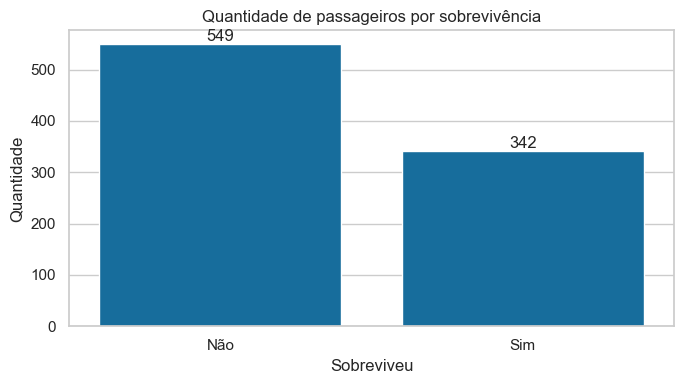

In [10]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x="sobreviveu", order=ordem_sobrevivencia)
ax.set(title="Quantidade de passageiros por sobrevivência", xlabel="Sobreviveu", ylabel="Quantidade")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

**Gráfico 1.** Houve 549 não sobreviventes e 342 sobreviventes.

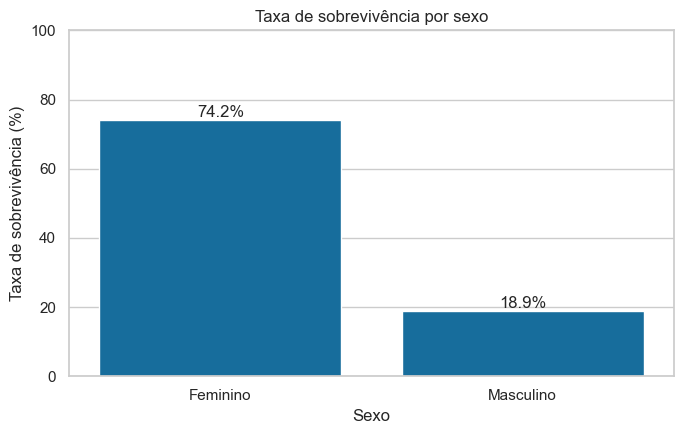

In [11]:
taxa_sexo_plot = taxa_por_sexo.reset_index()

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(data=taxa_sexo_plot, x="sexo", y="taxa_sobrevivencia", order=ordem_sexo)
ax.set(title="Taxa de sobrevivência por sexo", xlabel="Sexo", ylabel="Taxa de sobrevivência (%)", ylim=(0, 100))
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.tight_layout()
plt.show()

**Gráfico 2.** A sobrevivência foi de 74,2% entre mulheres e 18,9% entre homens, indicando forte associação com sexo.

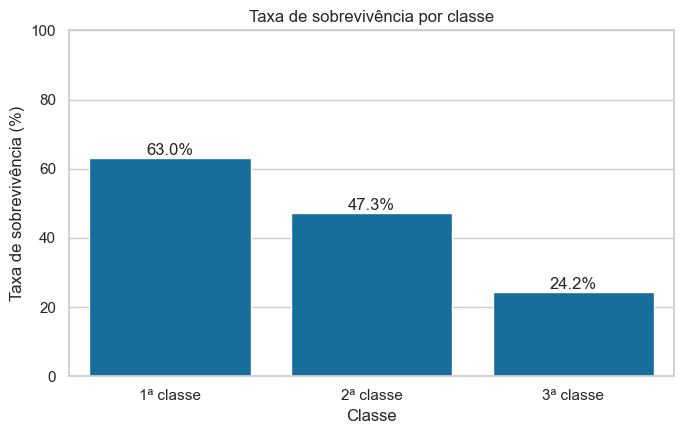

In [12]:
taxa_classe_plot = taxa_por_classe.reset_index()

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(data=taxa_classe_plot, x="classe", y="taxa_sobrevivencia", order=ordem_classe)
ax.set(title="Taxa de sobrevivência por classe", xlabel="Classe", ylabel="Taxa de sobrevivência (%)", ylim=(0, 100))
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.tight_layout()
plt.show()

**Gráfico 3.** A sobrevivência diminui por classe: 63,0% na primeira, 47,3% na segunda e 24,2% na terceira.

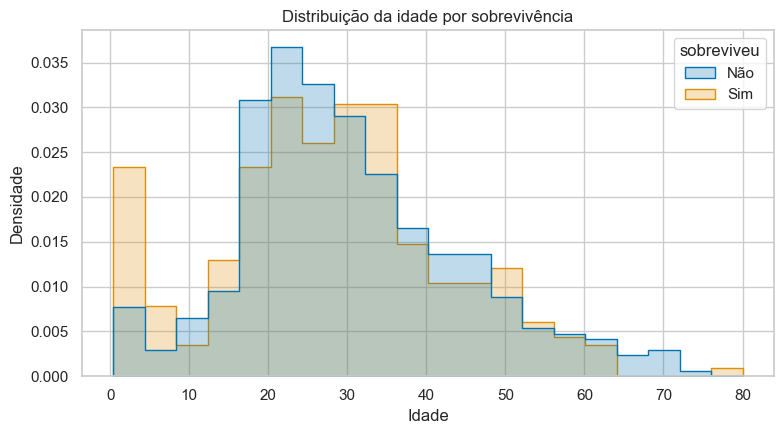

In [13]:
plt.figure(figsize=(8, 4.5))
sns.histplot(
    data=df,
    x="age",
    hue="sobreviveu",
    hue_order=ordem_sobrevivencia,
    bins=20,
    element="step",
    stat="density",
    common_norm=False,
    alpha=0.25,
)
plt.title("Distribuição da idade por sobrevivência")
plt.xlabel("Idade")
plt.ylabel("Densidade")
plt.tight_layout()
plt.show()

**Gráfico 4.** As distribuições de idade se sobrepõem. A diferença entre os grupos é pequena e considera apenas 714 idades conhecidas.

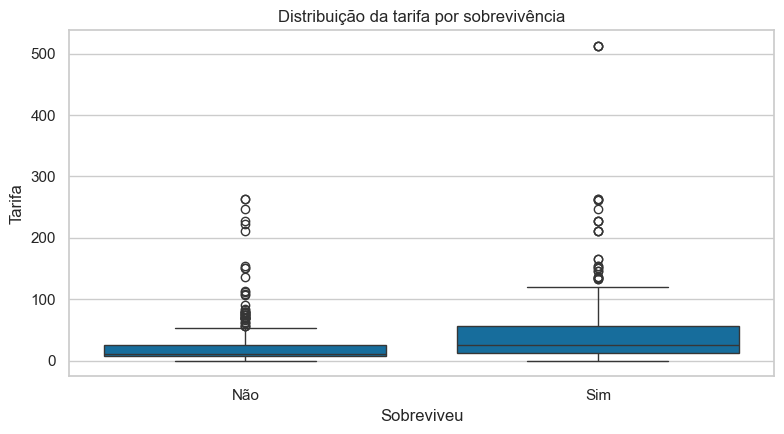

In [14]:
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df, x="sobreviveu", y="fare", order=ordem_sobrevivencia)
plt.title("Distribuição da tarifa por sobrevivência")
plt.xlabel("Sobreviveu")
plt.ylabel("Tarifa")
plt.tight_layout()
plt.show()

**Gráfico 5.** A tarifa mediana foi 26,00 entre sobreviventes e 10,50 entre não sobreviventes. Há vários valores elevados.

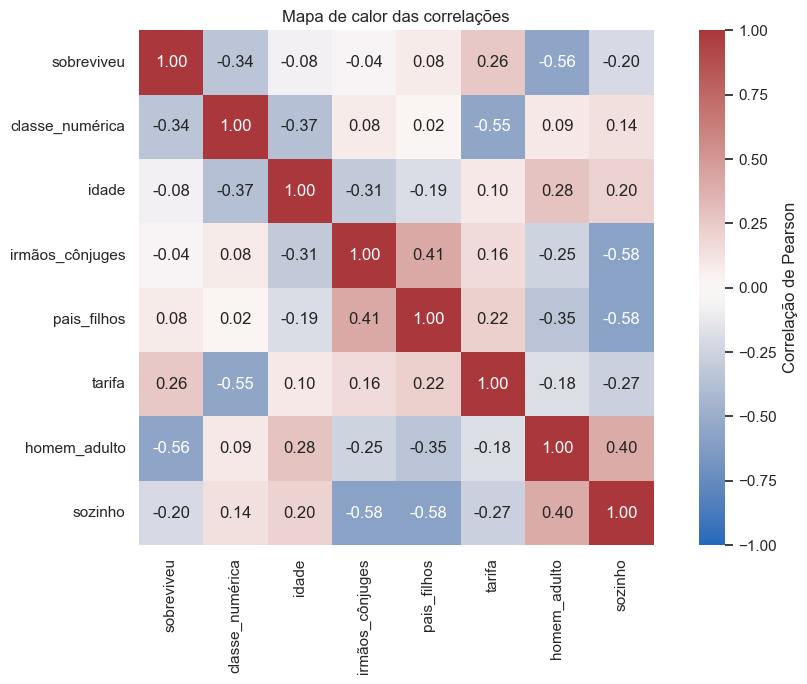

In [15]:
colunas_correlacao = ["survived", "pclass", "age", "sibsp", "parch", "fare", "adult_male", "alone"]
nomes_correlacao = {
    "survived": "sobreviveu",
    "pclass": "classe_numérica",
    "age": "idade",
    "sibsp": "irmãos_cônjuges",
    "parch": "pais_filhos",
    "fare": "tarifa",
    "adult_male": "homem_adulto",
    "alone": "sozinho",
}
correlacoes = (
    df[colunas_correlacao]
    .corr()
    .rename(index=nomes_correlacao, columns=nomes_correlacao)
)

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlacoes,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"label": "Correlação de Pearson"},
)
plt.title("Mapa de calor das correlações")
plt.tight_layout()
plt.show()

**Gráfico 6.** `homem_adulto` apresenta a maior correlação negativa com sobrevivência (-0,56). Classe numérica (-0,34) e tarifa (0,26) também possuem associação.

Correlação não implica causalidade.

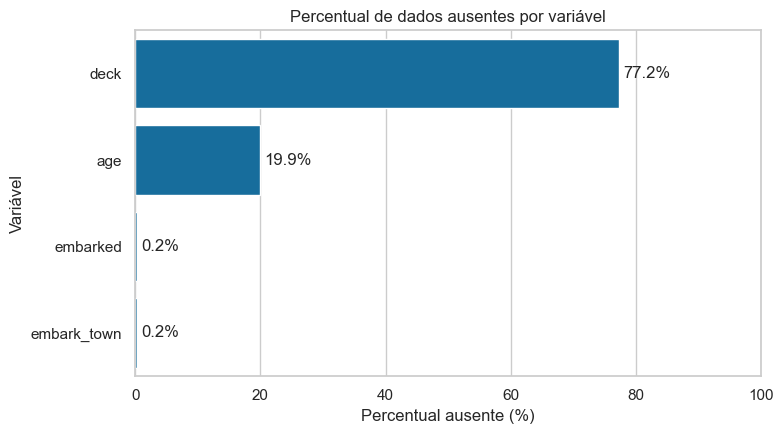

In [16]:
percentuais_ausentes = df_original.isna().mean().mul(100).sort_values(ascending=False)
percentuais_ausentes = percentuais_ausentes[percentuais_ausentes > 0]

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(x=percentuais_ausentes.values, y=percentuais_ausentes.index)
ax.set(
    title="Percentual de dados ausentes por variável",
    xlabel="Percentual ausente (%)",
    ylabel="Variável",
    xlim=(0, 100),
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

**Gráfico 7.** As ausências concentram-se em `deck` (77,2%) e `age` (19,9%). Análises do convés seriam pouco confiáveis.

## 5. Perguntas orientadoras

### Pergunta 1: como sexo e classe se relacionam com a sobrevivência?

São comparadas as taxas para cada combinação de sexo e classe.

In [17]:
resposta_q1 = (
    df.groupby(["sexo", "classe"], observed=True)["survived"]
    .agg(passageiros="size", sobreviventes="sum", taxa_sobrevivencia="mean")
)
resposta_q1["taxa_sobrevivencia"] *= 100
resposta_q1.round(1)

passageiros  sobreviventes  taxa_sobrevivencia
sexo      classe                                                   
Feminino  1ª classe           94             91                96.8
          2ª classe           76             70                92.1
          3ª classe          144             72                50.0
Masculino 1ª classe          122             45                36.9
          2ª classe          108             17                15.7
          3ª classe          347             47                13.5

**Resposta.** Entre mulheres, as taxas foram 96,8%, 92,1% e 50,0% da primeira à terceira classe. Entre homens, foram 36,9%, 15,7% e 13,5%. Sexo e classe estão associados à sobrevivência.

### Pergunta 2: idade e tarifa diferem entre os grupos?

São comparadas média, mediana e dispersão.

In [18]:
resposta_q2 = (
    df.groupby("sobreviveu", observed=True)[["age", "fare"]]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)
resposta_q2

age                       fare                     
           count   mean median    std count   mean median    std
sobreviveu                                                      
Não          424  30.63   28.0  14.17   549  22.12   10.5  31.39
Sim          290  28.34   28.0  14.95   342  48.40   26.0  66.60

In [19]:
idade_media = df.groupby("sobreviveu", observed=True)["age"].mean()
tarifa_mediana = df.groupby("sobreviveu", observed=True)["fare"].median()

print(f"Diferença de idade média (não sobreviventes - sobreviventes): {idade_media['Não'] - idade_media['Sim']:.2f} anos")
print(f"Diferença de tarifa mediana (sobreviventes - não sobreviventes): {tarifa_mediana['Sim'] - tarifa_mediana['Não']:.2f}")

Diferença de idade média (não sobreviventes - sobreviventes): 2.28 anos
Diferença de tarifa mediana (sobreviventes - não sobreviventes): 15.50


**Resposta.** A idade média foi 28,34 anos entre sobreviventes e 30,63 entre não sobreviventes. A diferença é pequena e as medianas são iguais a 28 anos.

A tarifa mediana foi 26,00 entre sobreviventes e 10,50 entre não sobreviventes.

### Pergunta 3: a média representa bem as tarifas?

São comparadas medidas de centro, dispersão e assimetria.

In [20]:
resposta_q3 = pd.Series({
    "media": df["fare"].mean(),
    "mediana": df["fare"].median(),
    "q1": df["fare"].quantile(0.25),
    "q3": df["fare"].quantile(0.75),
    "IQR": df["fare"].quantile(0.75) - df["fare"].quantile(0.25),
    "desvio_padrao": df["fare"].std(),
    "maximo": df["fare"].max(),
    "assimetria": df["fare"].skew(),
})
resposta_q3.round(3).to_frame("tarifa")

,tarifa
media,32.204
mediana,14.454
q1,7.910
q3,31.000
IQR,23.090
desvio_padrao,49.693
maximo,512.329
assimetria,4.787


**Resposta.** Não isoladamente. A média é 32,20 e a mediana, 14,45. A assimetria de 4,79 e o máximo de 512,33 mostram influência de poucos valores altos. Mediana e IQR são medidas mais robustas.

## 6. Conclusão

A taxa geral de sobrevivência foi 38,4%, com diferenças por sexo e classe. A idade apresentou pouca diferença entre os grupos, enquanto a tarifa foi maior entre sobreviventes e possui forte assimetria.

Os resultados mostram associações, não causalidade. As principais limitações são valores ausentes em `age` e `deck`.
